# m19: HD–RF circular correlation — three schemes

Directly pair **session 11 saved TC** with **session 2 RF**, Probe A. Reuse the existing HD Class 3 selection.

1. All Class 3 cells with a defined RF maximum.
2. Class 3 cells with a saved excitatory 2D RF detection.
3. Scheme 2 cells whose `wrap360(HD + RF)` falls in its three most populated polar histogram bins.

RF position means the horizontal coordinate of the **global maximum bin in the native 2D response map**, after occupancy normalization and summing the 0–200 ms response. No horizontal projection, interpolation, smoothing, or additional RF quality filter is applied. The maximum need not lie inside the detection mask; the mask selects cells only.

The saved TC is counterclockwise; negate its preferred angle once to express both HD and RF clockwise. The source file remains unchanged.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display

from Utils.hd_rf_schemes import load_peak_pairs, select_schemes
from Utils.hd_rf_circular_regression import fit_circular_conversion, predict_circular_conversion
assert '/home/kai/.virtualenvs/rfmapping' in sys.executable, sys.executable
print(sys.executable)

root = Path('/mnt/senzailab/Kai/#Recording/m19/260827')
hd_file = root / '260827_11/data/tuning_curves/ProbeA/tuning_curves.json'
rf_file = root / '260827_2/data/rfmapping/good/-100_400_1ms/ProbeA/regular_unitsSpikeCounts_260827_2.rfmap'
output = Path('output/hd_rf_schemes/m19_260827_hd11_rf2')
output.mkdir(parents=True, exist_ok=True)
polar_bins = 30
top_n_bins = 3
n_permutations = 10_000
random_seed = 1
query = np.linspace(0., 360., 1441)

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'savefig.facecolor': 'white', 'savefig.transparent': False,
                     'text.color': '#17212b', 'axes.labelcolor': '#17212b',
                     'xtick.color': '#17212b', 'ytick.color': '#17212b',
                     'font.size': 11})

/home/kai/.virtualenvs/rfmapping/bin/python


## Load the saved sources

HD profiles use the existing 30-bin, unsmoothed TC reader. Keep source angles alongside the converted clockwise angles for audit. Undefined peaks are reported instead of silently removed from the source inventory.

In [2]:
# Data-loader settings and selection details are saved with every result.
all_pairs, provenance = load_peak_pairs(hd_file, rf_file, hd_is_clockwise=False)
schemes, selection = select_schemes(all_pairs, n_bins=polar_bins, top_n_bins=top_n_bins)
for name, pairs in schemes.items():
    all_pairs[name] = all_pairs.unit_id.isin(pairs.unit_id)
all_pairs.to_csv(output / 'all_pairs.csv', index=False)
for name, pairs in schemes.items():
    pairs.to_csv(output / f'{name}.csv', index=False)
(output / 'provenance.json').write_text(json.dumps(provenance, indent=2) + '\n')
(output / 'selection_manifest.json').write_text(json.dumps(selection, indent=2) + '\n')
display(all_pairs)

,mouse,date,probe,unit_id,hd_class,hd_native_preferred_deg,hd_preferred_deg,hd_peak_hz,hd_peak_ties,rf_map_present,...,rf_peak_in_saved_2d_mask,rf_finite_bins,rf_zero_bins,rf_missing_bins,hd_plus_rf_deg,peak_valid,exclusion_reason,scheme1,scheme2,scheme3
0,m19,260827,A,75,3,246.0,114.0,6.241669,1,True,...,True,210,0,0,216.0,True,,True,True,False
1,m19,260827,A,104,3,246.0,114.0,29.162758,1,True,...,False,210,0,0,60.0,True,,True,False,False
2,m19,260827,A,124,3,54.0,306.0,82.508166,1,True,...,True,210,0,0,264.0,True,,True,True,False
3,m19,260827,A,134,3,210.0,150.0,35.406474,1,True,...,False,210,0,0,144.0,True,,True,True,True
4,m19,260827,A,135,3,246.0,114.0,69.445128,1,True,...,True,210,0,0,168.0,True,,True,True,True
5,m19,260827,A,136,3,222.0,138.0,84.468833,1,True,...,True,210,0,0,168.0,True,,True,True,True
6,m19,260827,A,146,3,54.0,306.0,4.263487,1,True,...,True,210,2,0,192.0,True,,True,True,False
7,m19,260827,A,147,3,54.0,306.0,58.186910,1,True,...,True,210,0,0,192.0,True,,True,True,False
8,m19,260827,A,170,3,210.0,150.0,39.570711,1,True,...,True,210,0,0,144.0,True,,True,True,True
9,m19,260827,A,177,3,246.0,114.0,25.386285,1,True,...,False,210,0,0,240.0,True,,True,False,False


## Circular association and fitted RF direction

Signed Fisher–Lee circular–circular correlation measures the association independently of the regression; it can be negative or positive. Schemes 1 and 2 use a seeded, two-sided permutation test that shuffles cell pairings.

The population conversion is a **first-harmonic circular regression**. Ordinary least squares separately fits the cosine and sine of the observed RF angle using the three predictors 1, cos(HD), and sin(HD):

\[
C(h)=a_0+a_c\cos h+a_s\sin h,\qquad
S(h)=b_0+b_c\cos h+b_s\sin h,
\]
\[
\widehat{RF}_{ego}(h)=\operatorname{atan2}(S(h),C(h)),\qquad
\widehat{RF}_{allo}(h)=\operatorname{wrap}_{360}\!\left(h+\widehat{RF}_{ego}(h)\right).
\]

Trigonometric calculations use radians; saved and plotted angles use degrees. All six coefficients are estimated from the selected paired cells. The fitted RF direction is periodic in HD, and the derived allocentric direction may vary with HD. Reported MAE is the **in-sample circular error**, not held-out prediction accuracy.

**Scheme 3 is selected using HD + RF itself.** Its correlation and fitted error describe that selected subset; they are not independent evidence that the relation is stronger. No unadjusted significance test is reported for this subset.

Circular-correlation method: [Fisher & Lee, 1983](https://doi.org/10.1093/biomet/70.2.327); [reference implementation documentation](https://circstat.github.io/pycircstat2/reference/correlation/).


In [3]:
labels = {'scheme1': '1 · All HD Class 3',
          'scheme2': '2 · Class 3 + 2D RF',
          'scheme3': '3 · Scheme 2 + top 3 sum bins'}
results = {}
rows = []
for name, pairs in schemes.items():
    result = fit_circular_conversion(pairs.hd_preferred_deg.to_numpy(), pairs.rf_ego_deg.to_numpy(),
                                     selected_on_sum=name == 'scheme3',
                                     n_permutations=n_permutations, random_seed=random_seed)
    assert result['method'] == 'first_harmonic_circular_regression'
    results[name] = result
    predicted = predict_circular_conversion(query, result)
    assert np.isfinite(predicted['rf_ego_deg']).all()
    allo_unwrapped = np.rad2deg(np.unwrap(np.deg2rad(predicted['rf_allo_deg'])))
    row = {'scheme': name, 'n': result['n'], 'rho_circular': result['rho'],
           'permutation_p': result['permutation_p'], 'fit_mae_deg': result['mae_deg'],
           'predicted_rf_allo_span_deg': float(np.ptp(allo_unwrapped)),
           'method': result['method'],
           'inference': 'descriptive; selected on HD+RF' if name == 'scheme3' else 'two-sided permutation'}
    row.update(zip(['cos_intercept', 'cos_hd_cos', 'cos_hd_sin'], result['cos_coefficients'], strict=True))
    row.update(zip(['sin_intercept', 'sin_hd_cos', 'sin_hd_sin'], result['sin_coefficients'], strict=True))
    rows.append(row)
summary = pd.DataFrame(rows)
summary.to_csv(output / 'correlation_summary.csv', index=False)
display(summary[['scheme', 'n', 'rho_circular', 'permutation_p', 'fit_mae_deg',
                 'predicted_rf_allo_span_deg', 'inference']])


,scheme,n,rho_circular,permutation_p,fit_mae_deg,predicted_rf_allo_span_deg,inference
0,scheme1,18,-0.259145,0.011299,37.928587,109.136116,two-sided permutation
1,scheme2,13,-0.715050,0.000100,16.999197,74.498978,two-sided permutation
2,scheme3,8,-0.950029,NaN,7.272687,45.068890,descriptive; selected on HD+RF


## Compare all three schemes

Top: measured HD/RF pairs and the continuous fitted RF direction. Bottom: the **observed** HD + RF distributions, always using **30 bins of 12°, starting at 0°**. Scheme 2's three highest-count bins define scheme 3. Ties are resolved by lower bin angle and recorded in the selection manifest. The model correction does not change these cohorts or histograms.


In [4]:
edges = np.linspace(0., 360., polar_bins + 1)
counts2, _ = np.histogram(schemes['scheme2'].hd_plus_rf_deg % 360, edges)
ranked = sorted(range(polar_bins), key=lambda i: (-counts2[i], i))
top_bins = [i for i in ranked[:top_n_bins] if counts2[i] > 0]
ranking = pd.DataFrame({'rank': np.arange(1, polar_bins + 1), 'bin_index': ranked,
                        'start_deg': edges[ranked], 'end_deg': edges[np.array(ranked) + 1],
                        'scheme2_count': counts2[ranked],
                        'selected': [i in top_bins for i in ranked]})
ranking.to_csv(output / 'polar_bin_ranking.csv', index=False)
display(ranking.head(8))

,rank,bin_index,start_deg,end_deg,scheme2_count,selected
0,1,12,144.0,156.0,3,True
1,2,14,168.0,180.0,3,True
2,3,11,132.0,144.0,2,True
3,4,16,192.0,204.0,2,False
4,5,9,108.0,120.0,1,False
5,6,18,216.0,228.0,1,False
6,7,22,264.0,276.0,1,False
7,8,0,0.0,12.0,0,False


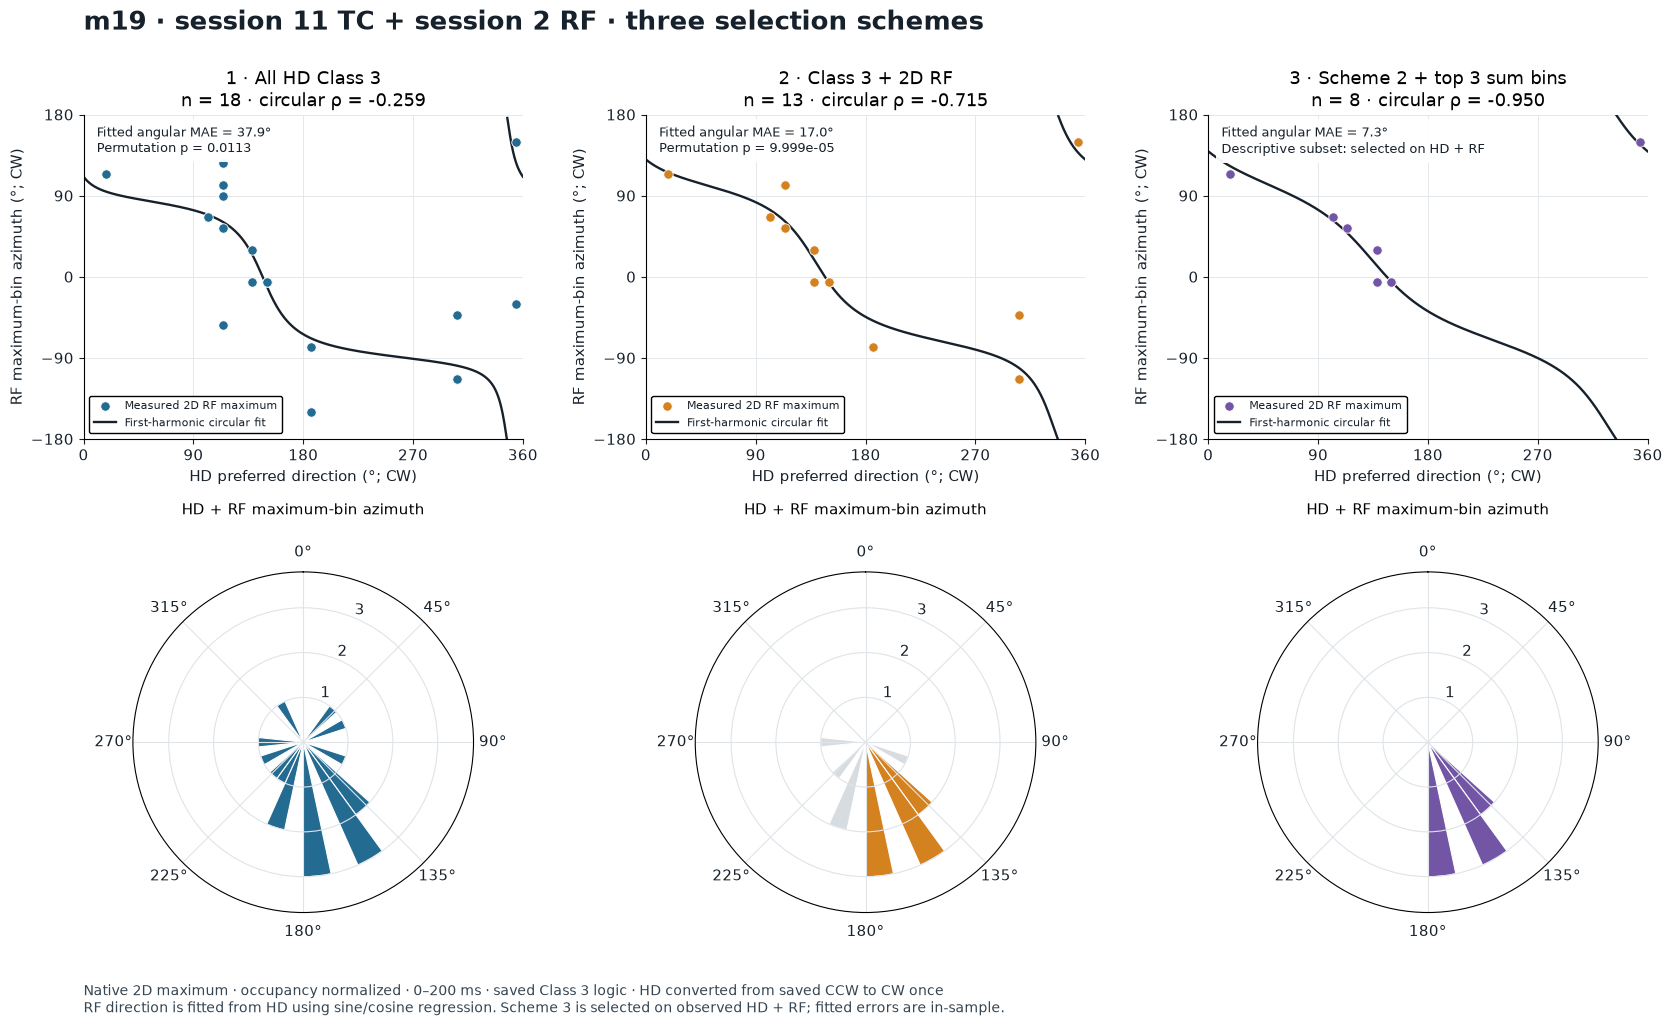

In [5]:
fig = plt.figure(figsize=(17, 10.5), facecolor='white')
grid = fig.add_gridspec(2, 3, height_ratios=[1, 1.05], hspace=.40, wspace=.28)
colors = ['#246b91', '#d4811f', '#7355a5']
max_count = max(np.histogram(p.hd_plus_rf_deg % 360, edges)[0].max() for p in schemes.values())
for column, ((name, pairs), color) in enumerate(zip(schemes.items(), colors)):
    result = results[name]
    ax = fig.add_subplot(grid[0, column])
    curve = predict_circular_conversion(query, result)['rf_ego_deg']
    curve = np.asarray(curve).copy()
    curve[np.r_[False, np.abs(np.diff(curve)) > 180]] = np.nan
    ax.scatter(pairs.hd_preferred_deg, pairs.rf_ego_deg, s=46, color=color,
               edgecolor='white', linewidth=.6, zorder=3, label='Measured 2D RF maximum')
    ax.plot(query, curve, color='#17212b', lw=1.7, label='First-harmonic circular fit')
    ax.set(xlim=(0, 360), ylim=(-180, 180), xticks=[0, 90, 180, 270, 360],
           yticks=[-180, -90, 0, 90, 180], xlabel='HD preferred direction (°; CW)',
           ylabel='RF maximum-bin azimuth (°; CW)', title=f"{labels[name]}\nn = {result['n']} · circular ρ = {result['rho']:.3f}")
    p = result['permutation_p']
    note = f"Fitted angular MAE = {result['mae_deg']:.1f}°"
    note += f"\nPermutation p = {p:.4g}" if p is not None else '\nDescriptive subset: selected on HD + RF'
    ax.text(.03, .97, note, ha='left', va='top', transform=ax.transAxes, fontsize=9,
            bbox=dict(facecolor='white', edgecolor='none', alpha=.95))
    ax.grid(color='#e4e8eb', lw=.7)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(loc='lower left', fontsize=8, facecolor='white', framealpha=1)
    polar = fig.add_subplot(grid[1, column], projection='polar')
    counts, _ = np.histogram(pairs.hd_plus_rf_deg % 360, edges)
    bar_colors = [color if name == 'scheme1' or i in top_bins else '#d7dce0' for i in range(polar_bins)]
    polar.bar(np.deg2rad((edges[:-1] + edges[1:]) / 2), counts,
              width=np.deg2rad(12), color=bar_colors, edgecolor='white', linewidth=.8)
    polar.set_theta_zero_location('N')
    polar.set_theta_direction(-1)
    polar.set_ylim(0, max_count + .8)
    polar.yaxis.set_major_locator(MaxNLocator(integer=True))
    polar.grid(color='#dfe4e8')
    polar.set_title('HD + RF maximum-bin azimuth', pad=22, fontsize=11)
fig.suptitle('m19 · session 11 TC + session 2 RF · three selection schemes',
             fontsize=19, fontweight='bold', x=.06, ha='left', y=.98)
fig.text(.06, .025, 'Native 2D maximum · occupancy normalized · 0–200 ms · saved Class 3 logic · HD converted from saved CCW to CW once\n'
                   'RF direction is fitted from HD using sine/cosine regression. Scheme 3 is selected on observed HD + RF; fitted errors are in-sample.',
         fontsize=10, color='#354551')
fig.subplots_adjust(left=.06, right=.98, top=.88, bottom=.12)
fig.savefig(output / 'three_schemes.png', dpi=180, facecolor='white', transparent=False)
plt.show()

## Derived allocentric prediction

For each input HD, add the fitted RF ego angle to that HD and wrap to 0–360°. These curves are model predictions. The dots are the measured preferred HD + RF sums for the same cells. The reported curve span is measured after continuous unwrapping so crossing 0° does not create a false jump.


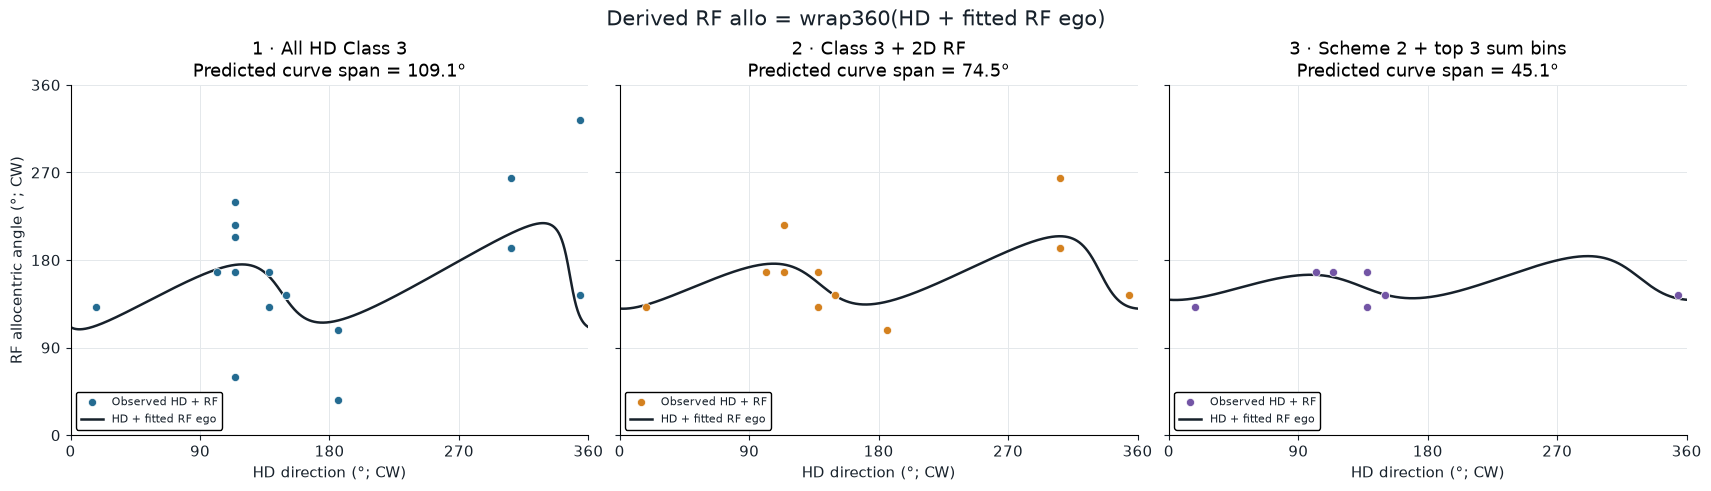

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharex=True, sharey=True,
                         layout='constrained', facecolor='white')
for ax, (name, pairs), color in zip(axes, schemes.items(), colors, strict=True):
    predicted = predict_circular_conversion(query, results[name])
    allo = np.asarray(predicted['rf_allo_deg']).copy()
    allo[np.r_[False, np.abs(np.diff(allo)) > 180]] = np.nan
    ax.scatter(pairs.hd_preferred_deg, pairs.hd_plus_rf_deg, s=34, color=color,
               edgecolor='white', linewidth=.5, label='Observed HD + RF', zorder=3)
    ax.plot(query, allo, color='#17212b', lw=1.8, label='HD + fitted RF ego')
    span = summary.set_index('scheme').loc[name, 'predicted_rf_allo_span_deg']
    ax.set(title=f"{labels[name]}\nPredicted curve span = {span:.1f}°",
           xlim=(0, 360), ylim=(0, 360), xticks=[0, 90, 180, 270, 360],
           yticks=[0, 90, 180, 270, 360], xlabel='HD direction (°; CW)')
    ax.grid(color='#e4e8eb', lw=.7)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8, facecolor='white', framealpha=1, loc='lower left')
axes[0].set_ylabel('RF allocentric angle (°; CW)')
fig.suptitle('Derived RF allo = wrap360(HD + fitted RF ego)', fontsize=15)
fig.savefig(output / 'predicted_allocentric_curves.png', dpi=180, facecolor='white', transparent=False)
plt.show()


## Save the fitted conversion

The JSON files contain the fitted cosine/sine coefficients in basis order 1, cos(HD), sin(HD). Dense angle grids provide both predicted RF ego and the derived RF allo for the population video. A 360° input turn returns to the same predicted RF direction. The model predicts a population preference relation from behavioral HD; it does not measure a neuron's RF on each video frame.


In [7]:
models = {}
for name, pairs in schemes.items():
    result = results[name]
    model = {'method': result['method'], 'scheme': name, 'n': result['n'],
             'cos_coefficients': result['cos_coefficients'],
             'sin_coefficients': result['sin_coefficients'],
             'basis': ['1', 'cos(HD)', 'sin(HD)'],
             'rho_circular': result['rho'], 'permutation_p': result['permutation_p'],
             'fit_mae_deg': result['mae_deg'],
             'selected_on_sum': name == 'scheme3', 'provenance': provenance,
             'selected_units': pairs.unit_id.astype(int).tolist(),
             'angle_convention': 'HD and RF ego clockwise; RF allo = wrap360(HD + RF ego)',
             'equation': 'RF ego = wrap180(atan2(X @ sin_coefficients, X @ cos_coefficients)); '
                         'X = [1, cos(HD), sin(HD)]; RF allo = wrap360(HD + RF ego)',
             'trigonometric_angle_units': 'radians; outputs in degrees',
             'fit_error_scope': 'in-sample circular MAE'}
    models[name] = model
    (output / f'{name}_conversion.json').write_text(json.dumps(model, indent=2, allow_nan=False) + '\n')
    predicted = predict_circular_conversion(query, model)
    pd.DataFrame({'hd_deg': query, **predicted}).to_csv(output / f'{name}_conversion_grid.csv', index=False)
(output / 'conversion_models.json').write_text(json.dumps(models, indent=2, allow_nan=False) + '\n')
print(f'Saved comparison, unit lists, polar-bin ranks, and fitted conversions to {output.resolve()}')


Saved comparison, unit lists, polar-bin ranks, and fitted conversions to /home/kai/Developer/rfmapping/output/hd_rf_schemes/m19_260827_hd11_rf2
